In [6]:
import warnings, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except Exception:
    PMDARIMA_AVAILABLE = False

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

SEASONAL_M   = 4   # quarterly
FUTURE_STEPS = 20  # 5 years (quarters)
DATA_DIR     = Path("data")

In [2]:
# load data files

from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd()

# the main dataset
rents_long = pd.read_csv(BASE_DIR / "one_flat_prelim_cleaning_4.csv")

# feature sets
crime = pd.read_csv(BASE_DIR / "crime_per_suburb.csv")            
hosp  = pd.read_csv(BASE_DIR / "hospital_per_suburb.csv")         
d_bus = pd.read_csv(BASE_DIR / "rentals_distances_to_bus_stops.csv")
d_trn = pd.read_csv(BASE_DIR / "rentals_distances_to_train_stops_and_cbd.csv")
d_trm = pd.read_csv(BASE_DIR / "rentals_distances_to_tram_stops.csv")
d_sch = pd.read_csv(BASE_DIR / "rentals_distances_to_schools.csv")

merged_features_expanded = rents_long.copy()

In [4]:
import warnings, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except Exception:
    PMDARIMA_AVAILABLE = False

warnings.filterwarnings("ignore")
SEASONAL_M, FUTURE_STEPS = 4, 20  # quarterly, 5 years

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    mask = (y_true != 0) & np.isfinite(y_true) & np.isfinite(y_pred)
    return np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100 if mask.any() else np.nan

def evaluate_forecast(y_true, y_pred, label="Model"):
    return {
        "model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE%": mape(y_true, y_pred),
    }

def coerce_rent_cols(df, date_col="Date", lga_col="Sub-Region", val_col="Median_Rent"):
    cols = {c.lower(): c for c in df.columns}
    def find(name_options):
        for opt in name_options:
            for k,v in cols.items():
                if opt in k: return v
        return None
    dc = find(["date","quarter"])
    lc = find(["sub-region","lga"])
    vc = find(["median_rent","weekly_rent","rent"])
    if dc and lc and vc:
        return df.rename(columns={dc:"Date", lc:"Sub-Region", vc:"Median_Rent"})
    raise ValueError("Could not find Date / LGA / Rent columns in rents_long.")

def make_quarterly_series(df, lga, lga_col="Sub-Region", date_col="Date", value_col="Median_Rent"):
    df = coerce_rent_cols(df, date_col, lga_col, value_col)
    sub = df.loc[df["Sub-Region"]==lga, ["Date","Median_Rent"]].copy()
    sub["Date"] = pd.to_datetime(sub["Date"], errors="coerce")
    sub = sub.dropna(subset=["Date"]).sort_values("Date")
    sub["QEnd"] = sub["Date"].dt.to_period("Q").dt.to_timestamp("Q")
    s = sub.groupby("QEnd")["Median_Rent"].mean().sort_index()
    full_idx = pd.period_range(s.index.min().to_period("Q"), s.index.max().to_period("Q"), freq="Q").to_timestamp("Q")
    ts = s.reindex(full_idx).asfreq("Q")
    ts_clean = ts.dropna()
    print(f"LGA {lga}: quarters={ts.notna().sum()} missing={ts.isna().sum()} clean={len(ts_clean)}")
    return ts, ts_clean

def split_series(ts, test_horizon=12, min_train=8):
    x = ts.dropna().sort_index()
    n = len(x)
    test_h = min(test_horizon, max(4, n//4))
    if n - test_h < min_train: test_h = max(4, n - min_train)
    return x.iloc[:-test_h], x.iloc[-test_h:]

def fit_sarima_auto(train, m=SEASONAL_M):
    if PMDARIMA_AVAILABLE:
        am = pm.auto_arima(train, seasonal=True, m=m, stepwise=True,
                           suppress_warnings=True, error_action="ignore",
                           max_p=3, max_q=3, max_P=2, max_Q=2, max_d=2, max_D=2)
        order, sorder = am.order, am.seasonal_order
        fit = SARIMAX(train, order=order, seasonal_order=sorder,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        return fit, order, sorder
    best = None
    for p in [0,1,2]:
        for d in [0,1,2]:
            for q in [0,1,2]:
                for P in [0,1]:
                    for D in [0,1]:
                        for Q in [0,1]:
                            try:
                                r = SARIMAX(train, order=(p,d,q), seasonal_order=(P,D,Q,m),
                                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                                if best is None or r.aic < best[0]: best = (r.aic,(p,d,q),(P,D,Q,m),r)
                            except: pass
    return best[3], best[1], best[2] if best else (SARIMAX(train,(1,1,1),(0,0,0,0)).fit(disp=False),(1,1,1),(0,0,0,0))

In [6]:
# build local governent area (LGA) features

from sklearn.preprocessing import MinMaxScaler
from ast import literal_eval
import numpy as np
import pandas as pd

def norm_suburb(s): return str(s).strip().lower()

# start from rent table: region/suburb/date/median
listings = pd.read_csv(BASE_DIR / "one_flat_prelim_cleaning_4.csv").rename(
    columns={"region":"Sub-Region", "suburb":"suburb", "date":"Date", "median":"Median_Rent", "count":"Count"}
)
listings["suburb"] = listings["suburb"].map(norm_suburb)

crime["suburb"] = crime["Suburb/Town Name"].map(norm_suburb)
hosp["suburb"]  = hosp["locality_name"].map(norm_suburb)

suburb_geo = pd.DataFrame(index=sorted(listings["suburb"].unique()))
suburb_geo = suburb_geo.join(crime.set_index("suburb")[["Offence Count"]], how="left")
suburb_geo = suburb_geo.join(hosp.set_index("suburb")[["num_hospitals"]], how="left")

def _to_list_safe(x):
    if pd.isna(x): return []
    try:
        v = literal_eval(str(x))
        if isinstance(v, (list, tuple)): return [float(z) for z in v]
    except Exception:
        pass
    return []

def _min_or_nan(seq): return np.min(seq) if len(seq) else np.nan

def try_add_distance_feature(dist_df, col_name, also_cols=None):
    """Tries to add a distance feature by *assuming* rental_id in dist_df matches a synthetic range.
       If coverage is too low (<10%), the column is auto-dropped."""
    df = dist_df.copy()
    if not np.issubdtype(df["rental_id"].dtype, np.number):
        df = df.reset_index(drop=True)
        df["rental_id"] = np.arange(1, len(df)+1)
    # compute min distance
    if "top_distances" in df.columns:
        df["min_dist"] = df["top_distances"].apply(_to_list_safe).apply(_min_or_nan)
    elif "min_dist" not in df.columns:
        return

    tmp = listings[["suburb"]].copy().reset_index(drop=True)
    tmp["rental_id"] = np.arange(1, len(tmp)+1)
    joined = tmp.merge(df[["rental_id","min_dist"] + ([also_cols] if also_cols else [])],
                       on="rental_id", how="left")

    # aggregate to suburb median
    agg = joined.groupby("suburb")["min_dist"].median()
    coverage = agg.notna().mean()
    if coverage < 0.10:
        # too sparse, skip
        print(f"Skipping {col_name}: insufficient coverage ({coverage:.1%}).")
        return
    # otherwise attach
    suburb_geo[col_name] = agg
    print(f"Added {col_name} with coverage {coverage:.1%}.")

try_add_distance_feature(d_bus, "closest_bus_distance")
try_add_distance_feature(d_trm, "closest_tram_distance")
try_add_distance_feature(d_sch, "closest_school_distance")
# CBD distance (comes from train file)
if "distance_to_cbd" in d_trn.columns:
    df_cbd = d_trn.copy()
    # map rental_id as above
    if not np.issubdtype(df_cbd["rental_id"].dtype, np.number):
        df_cbd = df_cbd.reset_index(drop=True)
        df_cbd["rental_id"] = np.arange(1, len(df_cbd)+1)
    tmp = listings[["suburb"]].copy().reset_index(drop=True)
    tmp["rental_id"] = np.arange(1, len(tmp)+1)
    cbd_join = tmp.merge(df_cbd[["rental_id","distance_to_cbd"]], on="rental_id", how="left")
    agg_cbd = cbd_join.groupby("suburb")["distance_to_cbd"].median()
    coverage = agg_cbd.notna().mean()
    if coverage >= 0.10:
        suburb_geo["distance_to_cbd"] = agg_cbd
        print(f"Added distance_to_cbd with coverage {coverage:.1%}.")
    else:
        print(f"Skipping distance_to_cbd: insufficient coverage ({coverage:.1%}).")

sg = suburb_geo.copy()

transport_cols = [c for c in ["closest_train_distance","closest_tram_distance","closest_bus_distance"] if c in sg.columns]
if len(transport_cols) >= 1:
    sg["mean_transport_distance"] = sg[transport_cols].mean(axis=1)
else:
    sg["mean_transport_distance"] = np.nan

sc = MinMaxScaler()

def scale_pos(col):
    v = sg[[col]].copy()
    v = v.fillna(v.median())  # avoids all-NaN scaler issues
    return sc.fit_transform(v)

def scale_inv(col):
    return 1 - scale_pos(col)

if "closest_school_distance" in sg.columns:
    sg["education_score"] = scale_inv("closest_school_distance")
else:
    sg["education_score"] = 0.0

if sg["mean_transport_distance"].notna().any():
    sg["infrastructure_score"] = 1 - sc.fit_transform(
        sg[["mean_transport_distance"]].fillna(sg["mean_transport_distance"].median())
    )
else:
    sg["infrastructure_score"] = 0.0

if "Offence Count" in sg.columns:
    sg["stability_score"] = 1 - sc.fit_transform(sg[["Offence Count"]].fillna(sg["Offence Count"].median()))
else:
    sg["stability_score"] = 0.0

if "num_hospitals" in sg.columns:
    sg["healthcare_score"] = scale_pos("num_hospitals")
else:
    sg["healthcare_score"] = 0.0

for c in ["education_score","infrastructure_score","stability_score","healthcare_score"]:
    if isinstance(sg[c], np.ndarray):  # if scaler returned ndarray
        sg[c] = sg[c].ravel()
    sg[c] = pd.to_numeric(sg[c], errors="coerce").fillna(0.0)

available_components = ["education_score","infrastructure_score","stability_score","healthcare_score"]
sg["livability_score"] = sg[available_components].mean(axis=1)

suburb_to_lga = listings.dropna(subset=["suburb","Sub-Region"]).drop_duplicates("suburb") \
                        .set_index("suburb")["Sub-Region"].rename("LGA")
sg = sg.join(suburb_to_lga)

agg_dict = {c:"median" for c in sg.columns if c not in ["LGA"]}
agg_dict.update({
    "education_score":"mean",
    "infrastructure_score":"mean",
    "stability_score":"mean",
    "healthcare_score":"mean",
    "livability_score":"mean",
})
lga_feats = sg.groupby("LGA").agg(agg_dict).rename_axis("LGA")

lga_feats = lga_feats.select_dtypes(include=[np.number])

display(lga_feats.head(10))

Skipping closest_bus_distance: insufficient coverage (0.0%).
Skipping closest_tram_distance: insufficient coverage (0.0%).
Skipping closest_school_distance: insufficient coverage (0.0%).
Skipping distance_to_cbd: insufficient coverage (0.0%).


,Offence Count,num_hospitals,mean_transport_distance,education_score,infrastructure_score,stability_score,healthcare_score,livability_score
LGA,,,,,,,,
Ballarat,NaN,NaN,NaN,0.0,0.0,0.807516,0.000000,0.201879
Bendigo,17097.0,2.0,NaN,0.0,0.0,0.810807,0.027778,0.209646
Geelong,8649.5,1.0,NaN,0.0,0.0,0.848275,0.000000,0.212069
Inner Eastern Melbourne,14476.0,4.0,NaN,0.0,0.0,0.830616,0.104575,0.233798
Inner Melbourne,23772.0,1.0,NaN,0.0,0.0,0.780340,0.055556,0.208974
Mornington Peninsula,75823.0,8.0,NaN,0.0,0.0,0.652972,0.155556,0.202132
North Eastern Melbourne,17799.0,2.0,NaN,0.0,0.0,0.750964,0.018519,0.192371
North Western Melbourne,27678.0,1.0,NaN,0.0,0.0,0.783830,0.008547,0.198094
Other Regional Centres,19031.0,1.0,NaN,0.0,0.0,0.728753,0.037037,0.191448


In [8]:
import numpy as np
import pandas as pd

lga_feats_safe = lga_feats.copy()

# replace inf with NaN first
lga_feats_safe = lga_feats_safe.replace([np.inf, -np.inf], np.nan)

# drop columns that are entirely NaN across all LGAs
all_nan_cols = [c for c in lga_feats_safe.columns if lga_feats_safe[c].isna().all()]
if all_nan_cols:
    print("Dropping all-NaN exogenous columns:", all_nan_cols)
    lga_feats_safe = lga_feats_safe.drop(columns=all_nan_cols)

# fill remaining NaNs with column median; if still NaN (constant NaN column), fill 0
lga_feats_safe = lga_feats_safe.apply(lambda col: col.fillna(col.median()))
lga_feats_safe = lga_feats_safe.fillna(0.0)

# keep only numeric columns
lga_feats_safe = lga_feats_safe.select_dtypes(include=[np.number])

# swap in the cleaned table
lga_feats = lga_feats_safe

print("lga_feats cleaned shape:", lga_feats.shape)
print("Any NaNs left?", lga_feats.isna().any().any())

Dropping all-NaN exogenous columns: ['mean_transport_distance']
lga_feats cleaned shape: (13, 7)
Any NaNs left? False


LGA Inner Melbourne: quarters=93 missing=0 clean=93
                                          MAE       RMSE      MAPE%
model                                                              
SARIMA(1, 2, 2)x(0, 1, 1, 4)        45.823476  51.018216  13.411173
SARIMAX(1, 2, 2)x(0, 1, 1, 4)+exog  47.664568  52.731472  13.934611


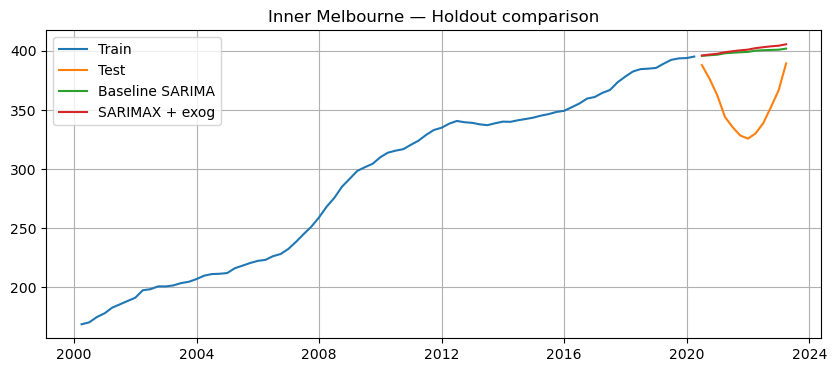

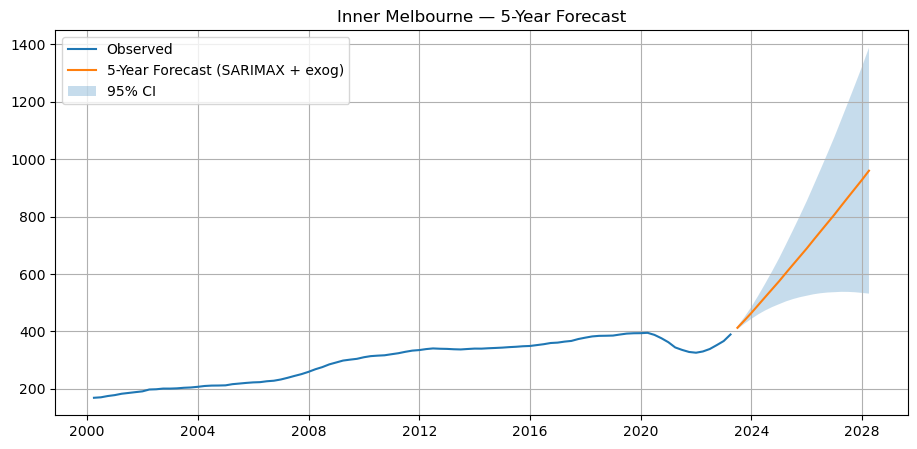

,Forecast_Median_Rent_$
2023-06-30,412.655794
2023-09-30,438.168052
2023-12-31,464.444002
2024-03-31,492.085869
2024-06-30,519.617944
2024-09-30,547.277388
2024-12-31,574.908065
2025-03-31,603.614441


In [10]:
def build_exog_for_lga(ts_index, target_lga: str):
    if target_lga not in lga_feats.index:
        raise ValueError(f"LGA '{target_lga}' not in lga_feats.")
    exog_row = lga_feats.loc[target_lga]
    X = pd.DataFrame([exog_row.values]*len(ts_index), index=ts_index, columns=lga_feats.columns)
    # quarter dummies (deterministic seasonality)
    q = pd.Index(ts_index).to_period("Q").quarter
    X["Q2"] = (q==2).astype(int); X["Q3"] = (q==3).astype(int); X["Q4"] = (q==4).astype(int)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X

target_lga = "Inner Melbourne" 
rents_long = listings[["Sub-Region","Date","Median_Rent"]].copy()
_, ts_clean = make_quarterly_series(rents_long, target_lga)
train, test = split_series(ts_clean, test_horizon=12)

try:
    fit_base, order, sorder = fit_sarima_auto(train, m=4)
except NameError:
    order, sorder = (1,1,1), (1,1,1,4)
    fit_base = SARIMAX(train, order=order, seasonal_order=sorder,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

X_all   = build_exog_for_lga(ts_clean.index, target_lga)
X_train = X_all.loc[train.index]
X_test  = X_all.loc[test.index]

assert np.isfinite(X_train.values).all() and np.isfinite(X_test.values).all(), "Exog still has non-finite values."

mod_ex = SARIMAX(train, order=order, seasonal_order=sorder,
                 exog=X_train, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
yhat_ex = mod_ex.forecast(steps=len(test), exog=X_test)
res_ex  = evaluate_forecast(test, yhat_ex, f"SARIMAX{order}x{sorder}+exog")

yhat_base = fit_base.forecast(steps=len(test))
res_base  = evaluate_forecast(test, yhat_base, f"SARIMA{order}x{sorder}")
print(pd.DataFrame([res_base, res_ex]).set_index("model"))

mod_full = SARIMAX(ts_clean, order=order, seasonal_order=sorder,
                   exog=X_all, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

FUTURE_STEPS = 20
future_idx = pd.period_range(ts_clean.index[-1].to_period("Q")+1, periods=FUTURE_STEPS, freq="Q").to_timestamp("Q")
X_future   = build_exog_for_lga(future_idx, target_lga)

fo = mod_full.get_forecast(steps=FUTURE_STEPS, exog=X_future)
fc = fo.predicted_mean
ci = fo.conf_int()

plt.figure(figsize=(10,4))
plt.plot(train.index, train.values, label="Train"); plt.plot(test.index, test.values, label="Test")
plt.plot(test.index, yhat_base, label="Baseline SARIMA")
plt.plot(test.index, yhat_ex, label="SARIMAX + exog")
plt.title(f"{target_lga} — Holdout comparison"); plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(11,5))
plt.plot(ts_clean.index, ts_clean.values, label="Observed")
plt.plot(fc.index, fc.values, label="5-Year Forecast (SARIMAX + exog)")
plt.fill_between(fc.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.25, label="95% CI")
plt.title(f"{target_lga} — 5-Year Forecast"); plt.grid(True); plt.legend(); plt.show()

fc.to_frame("Forecast_Median_Rent_$").head(8)

In [18]:
import pandas as pd
import numpy as np

def seasonal_naive(y: pd.Series, horizon: int, m: int = 4):
    return y.shift(m).dropna().iloc[-horizon:]

yhat_sn = seasonal_naive(ts_clean, len(test), m=4).reindex(test.index, method="nearest")
sn_res = evaluate_forecast(test, yhat_sn, "Seasonal Naive (m=4)")
print(pd.DataFrame([sn_res]))

                  model        MAE      RMSE     MAPE%
0  Seasonal Naive (m=4)  31.836957  36.76551  9.076025


LGA Inner Melbourne: quarters=93 missing=0 clean=93


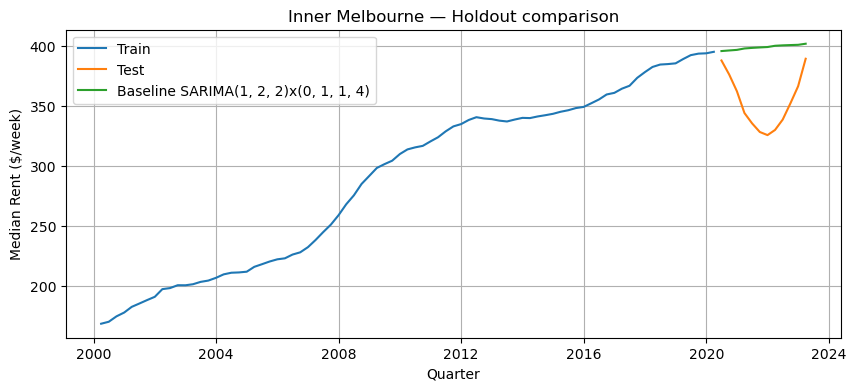

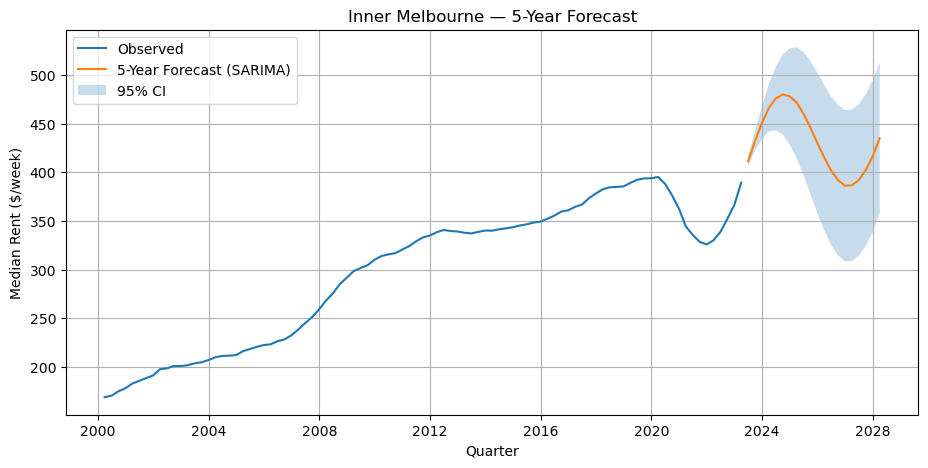

Saved:
 - slides_assets/Inner Melbourne_holdout.png
 - slides_assets/Inner Melbourne_forecast.png
 - slides_assets/Inner Melbourne_metrics.csv
 - slides_assets/Inner Melbourne_forecast_table.csv


In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings; warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("slides_assets"); OUTPUT_DIR.mkdir(exist_ok=True)

if "evaluate_forecast" not in globals():
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    import math
    def mape(y_true, y_pred):
        y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
        mask = (y_true != 0) & np.isfinite(y_true) & np.isfinite(y_pred)
        return np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100 if mask.any() else np.nan
    def evaluate_forecast(y_true, y_pred, label="Model"):
        return {"model": label,
                "MAE": mean_absolute_error(y_true, y_pred),
                "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
                "MAPE%": mape(y_true, y_pred)}

if "make_quarterly_series" not in globals():
    def make_quarterly_series(df, lga, lga_col="Sub-Region", date_col="Date", value_col="Median_Rent"):
        sub = df.loc[df[lga_col]==lga, [date_col, value_col]].copy()
        sub[date_col] = pd.to_datetime(sub[date_col], errors="coerce")
        sub = sub.dropna(subset=[date_col]).sort_values(date_col)
        sub["QEnd"] = sub[date_col].dt.to_period("Q").dt.to_timestamp("Q")
        s = sub.groupby("QEnd")[value_col].mean().sort_index()
        full_idx = pd.period_range(s.index.min().to_period("Q"), s.index.max().to_period("Q"), freq="Q").to_timestamp("Q")
        ts = s.reindex(full_idx).asfreq("Q")
        return ts, ts.dropna()

if "split_series" not in globals():
    def split_series(ts: pd.Series, test_horizon=12, min_train=8):
        x = ts.dropna().sort_index()
        n = len(x)
        test_h = min(test_horizon, max(4, n//4))
        if n - test_h < min_train:
            test_h = max(4, n - min_train)
        return x.iloc[:-test_h], x.iloc[-test_h:]

def fit_baseline(train):
    if "fit_sarima_auto" in globals():
        fit, order, sorder = fit_sarima_auto(train, m=4)
    else:
        order, sorder = (1,1,1), (1,1,1,4)
        fit = SARIMAX(train, order=order, seasonal_order=sorder,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return fit, order, sorder

rents_long = listings[["Sub-Region","Date","Median_Rent"]].copy()

target_lga = globals().get("target_lga", "Inner Melbourne")

ts, ts_clean = make_quarterly_series(rents_long, target_lga)
train, test = split_series(ts_clean, test_horizon=12)
fit_base, order, sorder = fit_baseline(train)
yhat_base = fit_base.forecast(steps=len(test))
res_base  = evaluate_forecast(test, yhat_base, f"SARIMA{order}x{sorder}")

plt.figure(figsize=(10,4))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index,  test.values,  label="Test")
plt.plot(test.index,  yhat_base,    label=f"Baseline SARIMA{order}x{sorder}")
plt.title(f"{target_lga} — Holdout comparison")
plt.xlabel("Quarter"); plt.ylabel("Median Rent ($/week)")
plt.grid(True); plt.legend()
holdout_path = OUTPUT_DIR / f"{target_lga}_holdout.png"
plt.savefig(holdout_path, bbox_inches="tight", dpi=160)
plt.show()

fit_full, order, sorder = fit_baseline(ts_clean)
FUTURE_STEPS = 20
fo = fit_full.get_forecast(steps=FUTURE_STEPS)
fc = fo.predicted_mean
ci = fo.conf_int()

plt.figure(figsize=(11,5))
plt.plot(ts_clean.index, ts_clean.values, label="Observed")
plt.plot(fc.index, fc.values, label="5-Year Forecast (SARIMA)")
plt.fill_between(fc.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.25, label="95% CI")
plt.title(f"{target_lga} — 5-Year Forecast")
plt.xlabel("Quarter"); plt.ylabel("Median Rent ($/week)")
plt.grid(True); plt.legend()
forecast_path = OUTPUT_DIR / f"{target_lga}_forecast.png"
plt.savefig(forecast_path, bbox_inches="tight", dpi=160)
plt.show()

metrics_rows = [res_base]

if "res_ex" in globals() and isinstance(res_ex, dict):
    metrics_rows.append(res_ex)
metrics_df = pd.DataFrame(metrics_rows).set_index("model")
metrics_csv = OUTPUT_DIR / f"{target_lga}_metrics.csv"
metrics_df.to_csv(metrics_csv)

forecast_csv = OUTPUT_DIR / f"{target_lga}_forecast_table.csv"
fc.to_frame("Forecast_Median_Rent_$").to_csv(forecast_csv)

print("Saved:")
print(" -", holdout_path)
print(" -", forecast_path)
print(" -", metrics_csv)
print(" -", forecast_csv)

In [16]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

FUTURE_STEPS = 20  # 5 years of quarters

if 'make_quarterly_series' not in globals():
    def make_quarterly_series(df, lga, lga_col='Sub-Region', date_col='Date', value_col='Median_Rent'):
        sub = df.loc[df[lga_col]==lga, [date_col, value_col]].copy()
        sub[date_col] = pd.to_datetime(sub[date_col], errors='coerce')
        sub = sub.dropna(subset=[date_col]).sort_values(date_col)
        sub['QEnd'] = sub[date_col].dt.to_period('Q').to_timestamp('Q')
        s = sub.groupby('QEnd')[value_col].mean().sort_index()
        full_idx = pd.period_range(s.index.min().to_period('Q'), s.index.max().to_period('Q'), freq='Q').to_timestamp('Q')
        ts = s.reindex(full_idx).asfreq('Q')
        return ts, ts.dropna()

def fit_baseline(train):
    if 'fit_sarima_auto' in globals():
        res, order, sorder = fit_sarima_auto(train, m=4)
    else:
        order, sorder = (1,1,1), (1,1,1,4)
        res = SARIMAX(train, order=order, seasonal_order=sorder,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return res, order, sorder

def _build_exog(ts_index, lga):
    """Return exogenous matrix if lga_feats exists and has this LGA; else None."""
    if 'lga_feats' not in globals() or lga not in lga_feats.index:
        return None
    row = lga_feats.loc[lga].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X = pd.DataFrame([row.values]*len(ts_index), index=ts_index, columns=list(lga_feats.columns))
    # quarter dummies
    q = pd.Index(ts_index).to_period('Q').quarter
    X['Q2'] = (q==2).astype(int); X['Q3'] = (q==3).astype(int); X['Q4'] = (q==4).astype(int)
    return X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

def forecast_next_5y_for_lga(lga):
    # Build quarterly series for this LGA
    rents_long = listings[['Sub-Region','Date','Median_Rent']].copy()
    _, ts_clean = make_quarterly_series(rents_long, lga)

    # Baseline fit on full history
    base_fit, order, sorder = fit_baseline(ts_clean)

    # Try exogenous if available; otherwise baseline
    future_idx = pd.period_range(ts_clean.index[-1].to_period('Q')+1, periods=FUTURE_STEPS, freq='Q').to_timestamp('Q')
    X_all = _build_exog(ts_clean.index, lga)
    if X_all is not None:
        mod = SARIMAX(ts_clean, order=order, seasonal_order=sorder,
                      exog=X_all, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        X_future = _build_exog(future_idx, lga)
        fo = mod.get_forecast(steps=FUTURE_STEPS, exog=X_future)
    else:
        fo = base_fit.get_forecast(steps=FUTURE_STEPS)

    fc = fo.predicted_mean
    ci = fo.conf_int()

    out = pd.DataFrame({
        'LGA': lga,
        'Quarter': fc.index,
        'Forecast_Median_Rent_$': fc.values,
        'Lower95': ci.iloc[:,0].values,
        'Upper95': ci.iloc[:,1].values,
    })
    return out

lgas = ["Geelong", "Inner Eastern Melbourne", "Southern Melbourne", "Outer Western Melbourne", "Ballarat"]

all_fc = pd.concat([forecast_next_5y_for_lga(l) for l in lgas], ignore_index=True)
display(all_fc.groupby('LGA').head(6))

LGA Geelong: quarters=93 missing=0 clean=93
LGA Inner Eastern Melbourne: quarters=93 missing=0 clean=93
LGA Southern Melbourne: quarters=93 missing=0 clean=93
LGA Outer Western Melbourne: quarters=93 missing=0 clean=93
LGA Ballarat: quarters=93 missing=0 clean=93


,LGA,Quarter,Forecast_Median_Rent_$,Lower95,Upper95
0,Geelong,2023-06-30,301.248632,296.619174,305.878091
1,Geelong,2023-09-30,308.540284,301.572202,315.508366
2,Geelong,2023-12-31,316.013609,306.349649,325.677569
3,Geelong,2024-03-31,323.659305,310.996097,336.322513
4,Geelong,2024-06-30,331.032656,314.977676,347.087636
5,Geelong,2024-09-30,338.609091,318.926987,358.291196
20,Inner Eastern Melbourne,2023-06-30,360.899618,353.568743,368.230493
21,Inner Eastern Melbourne,2023-09-30,366.546986,355.061216,378.032755
22,Inner Eastern Melbourne,2023-12-31,368.976908,352.370160,385.583656
23,Inner Eastern Melbourne,2024-03-31,371.465285,349.582308,393.348262


LGA Geelong: quarters=93 missing=0 clean=93


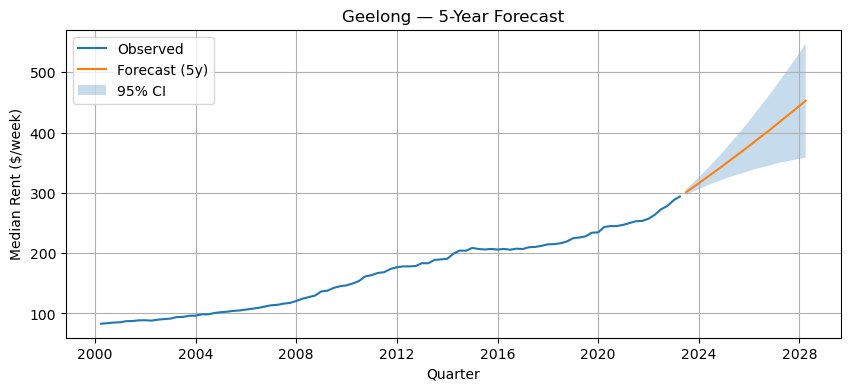

LGA Inner Eastern Melbourne: quarters=93 missing=0 clean=93


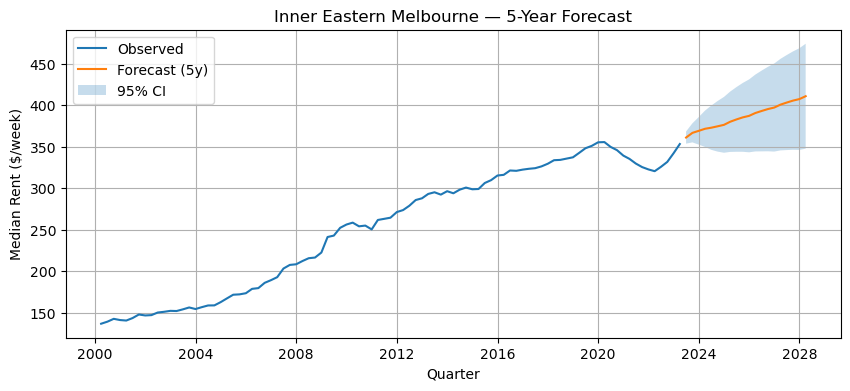

LGA Southern Melbourne: quarters=93 missing=0 clean=93


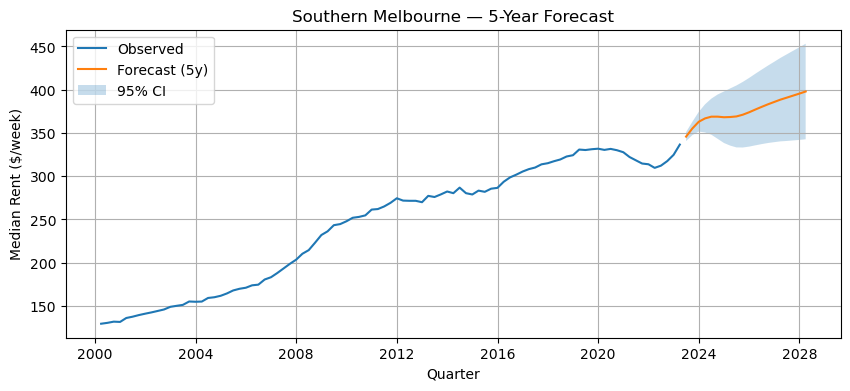

LGA Outer Western Melbourne: quarters=93 missing=0 clean=93


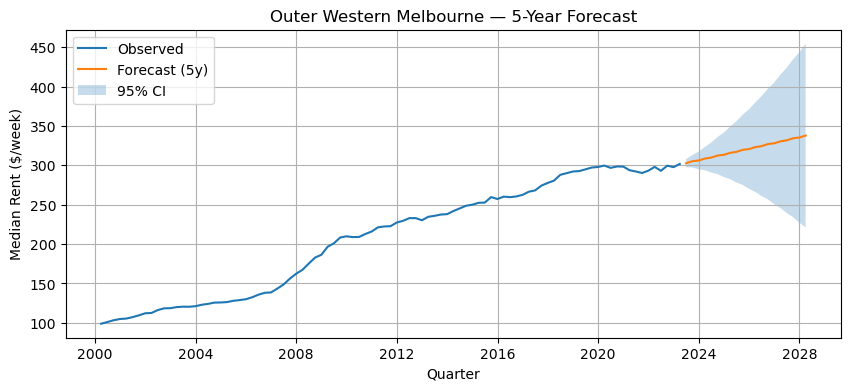

LGA Ballarat: quarters=93 missing=0 clean=93


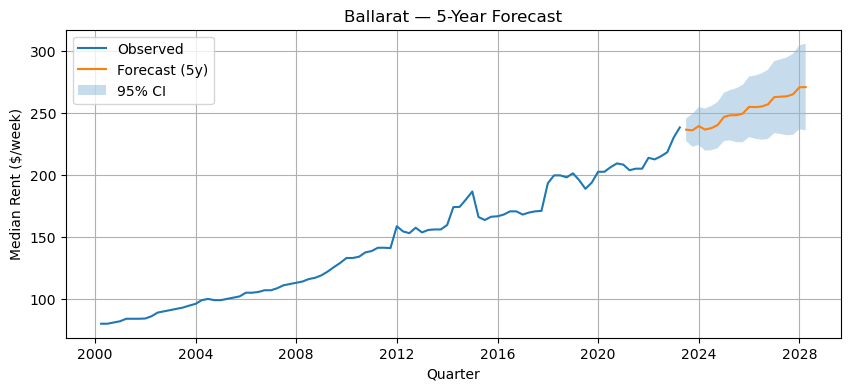

LGA Geelong: quarters=93 missing=0 clean=93
Saved: forecast_plots/Geelong_forecast.png
LGA Inner Eastern Melbourne: quarters=93 missing=0 clean=93
Saved: forecast_plots/Inner_Eastern_Melbourne_forecast.png
LGA Southern Melbourne: quarters=93 missing=0 clean=93
Saved: forecast_plots/Southern_Melbourne_forecast.png
LGA Outer Western Melbourne: quarters=93 missing=0 clean=93
Saved: forecast_plots/Outer_Western_Melbourne_forecast.png
LGA Ballarat: quarters=93 missing=0 clean=93
Saved: forecast_plots/Ballarat_forecast.png


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

FUTURE_STEPS = 20  # 5 years of quarters

if 'make_quarterly_series' not in globals():
    def make_quarterly_series(df, lga, lga_col='Sub-Region', date_col='Date', value_col='Median_Rent'):
        sub = df.loc[df[lga_col]==lga, [date_col, value_col]].copy()
        sub[date_col] = pd.to_datetime(sub[date_col], errors='coerce')
        sub = sub.dropna(subset=[date_col]).sort_values(date_col)
        sub['QEnd'] = sub[date_col].dt.to_period('Q').to_timestamp('Q')
        s = sub.groupby('QEnd')[value_col].mean().sort_index()
        full_idx = pd.period_range(s.index.min().to_period('Q'), s.index.max().to_period('Q'), freq='Q').to_timestamp('Q')
        ts = s.reindex(full_idx).asfreq('Q')
        return ts, ts.dropna()

def fit_baseline(train):
    if 'fit_sarima_auto' in globals():
        res, order, sorder = fit_sarima_auto(train, m=4)
    else:
        order, sorder = (1,1,1), (1,1,1,4)
        res = SARIMAX(train, order=order, seasonal_order=sorder,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return res, order, sorder

def _build_exog(ts_index, lga):
    """Return exog matrix if lga_feats exists & includes this LGA; else None."""
    if 'lga_feats' not in globals() or lga not in lga_feats.index:
        return None
    row = lga_feats.loc[lga].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X = pd.DataFrame([row.values]*len(ts_index), index=ts_index, columns=list(lga_feats.columns))
    q = pd.Index(ts_index).to_period('Q').quarter
    X['Q2'] = (q==2).astype(int); X['Q3'] = (q==3).astype(int); X['Q4'] = (q==4).astype(int)
    return X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

def forecast_components_for_lga(lga):
    rents_long = listings[['Sub-Region','Date','Median_Rent']].copy()
    _, ts_clean = make_quarterly_series(rents_long, lga)

    base_fit, order, sorder = fit_baseline(ts_clean)

    X_all = _build_exog(ts_clean.index, lga)
    if X_all is not None:
        mod = SARIMAX(ts_clean, order=order, seasonal_order=sorder,
                      exog=X_all, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        future_idx = pd.period_range(ts_clean.index[-1].to_period('Q')+1, periods=FUTURE_STEPS, freq='Q').to_timestamp('Q')
        X_future = _build_exog(future_idx, lga)
        fo = mod.get_forecast(steps=FUTURE_STEPS, exog=X_future)
    else:
        fo = base_fit.get_forecast(steps=FUTURE_STEPS)

    fc = fo.predicted_mean
    ci = fo.conf_int()
    return ts_clean, fc, ci

def plot_5y_forecast_for_lga(lga):
    ts_clean, fc, ci = forecast_components_for_lga(lga)
    plt.figure(figsize=(10,4))
    plt.plot(ts_clean.index, ts_clean.values, label="Observed")
    plt.plot(fc.index, fc.values, label="Forecast (5y)")
    plt.fill_between(fc.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.25, label="95% CI")
    plt.title(f"{lga} — 5-Year Forecast")
    plt.xlabel("Quarter"); plt.ylabel("Median Rent ($/week)")
    plt.grid(True); plt.legend()
    plt.show()

lgas = ["Geelong", "Inner Eastern Melbourne", "Southern Melbourne", "Outer Western Melbourne", "Ballarat"]

for lga in lgas:
    try:
        plot_5y_forecast_for_lga(lga)
    except Exception as e:
        print(f"Skipped {lga}: {e}")

import os
out_dir = "forecast_plots"
os.makedirs(out_dir, exist_ok=True)

for lga in lgas:
    try:
        ts_clean, fc, ci = forecast_components_for_lga(lga)
        plt.figure(figsize=(10,4))
        plt.plot(ts_clean.index, ts_clean.values, label="Observed")
        plt.plot(fc.index, fc.values, label="Forecast (5y)")
        plt.fill_between(fc.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.25, label="95% CI")
        plt.title(f"{lga} — 5-Year Forecast")
        plt.xlabel("Quarter"); plt.ylabel("Median Rent ($/week)")
        plt.grid(True); plt.legend()

        # Save as PNG in the folder
        filename = os.path.join(out_dir, f"{lga.replace(' ', '_')}_forecast.png")
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved: {filename}")
    except Exception as e:
        print(f"Skipped {lga}: {e}")

,suburb,LGA,last_obs_quarter,last_obs_$,end_quarter,end_fc_$,Total_%,CAGR_%
0,Castlemaine,Other Regional Centres,2022-06-30,278.0,36,1352.792078,386.615856,37.226268
1,North Melbourne-West Melbourne,Inner Melbourne,2023-03-31,399.0,2028-03-31 00:00:00,1394.712167,249.551921,28.440604
2,Carlton-Parkville,Inner Melbourne,2023-03-31,352.0,2028-03-31 00:00:00,988.912106,180.940939,22.948435
3,Caulfield,Southern Melbourne,2023-03-31,350.0,2028-03-31 00:00:00,821.959418,134.845548,18.619603
4,Carlton North,Inner Melbourne,2023-03-31,373.0,2028-03-31 00:00:00,864.411998,131.745844,18.304807
5,South Yarra,Inner Melbourne,2023-03-31,400.0,2028-03-31 00:00:00,769.133229,92.283307,13.969414
6,Toorak,Inner Melbourne,2023-03-31,358.0,2028-03-31 00:00:00,677.307475,89.192032,13.600585
7,Elwood,Inner Melbourne,2023-03-31,350.0,2028-03-31 00:00:00,630.861295,80.246084,12.505348
8,Carnegie,Southern Melbourne,2023-03-31,315.0,2028-03-31 00:00:00,552.343957,75.347288,11.887047
9,Fairfield-Alphington,North Eastern Melbourne,2023-03-31,315.0,2028-03-31 00:00:00,551.911515,75.210005,11.869521


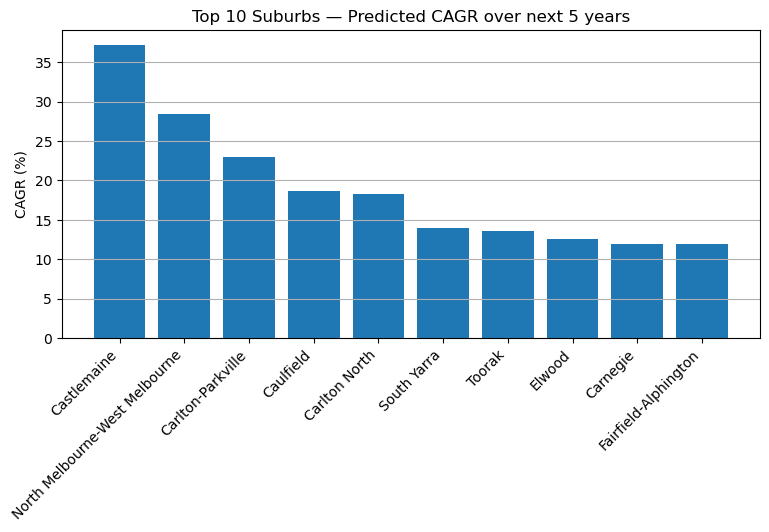

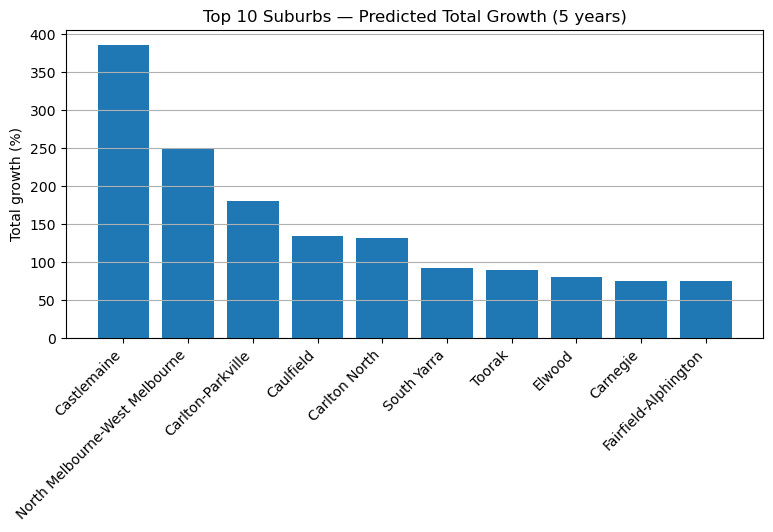

In [20]:
# top 10 suburbs
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

FUTURE_STEPS = 20   # 5 years of quarters
M_SEASON      = 4
MIN_POINTS    = 12  # require at least 3 years of quarterly data

if 'listings' not in globals():
    listings = pd.read_csv(BASE_DIR / "one_flat_prelim_cleaning_4.csv") \
                 .rename(columns={"region":"Sub-Region","suburb":"suburb","date":"Date","median":"Median_Rent","count":"Count"})

def make_q_series_suburb(df, suburb):
    sub_df = df.loc[df["suburb"]==suburb, ["Date","Median_Rent"]].copy()
    sub_df["Date"] = pd.to_datetime(sub_df["Date"], errors="coerce")
    sub_df = sub_df.dropna(subset=["Date"]).sort_values("Date")
    sub_df["QEnd"] = sub_df["Date"].dt.to_period("Q").dt.to_timestamp("Q")
    s = sub_df.groupby("QEnd")["Median_Rent"].mean().sort_index()
    if s.empty: 
        return None, None
    full_idx = pd.period_range(s.index.min().to_period("Q"), s.index.max().to_period("Q"), freq="Q").to_timestamp("Q")
    s = s.reindex(full_idx).asfreq("Q")
    return s, s.dropna()

# seasonal-naive fallback
def seasonal_naive(ts, steps, m=M_SEASON):
    if len(ts) < m:  # not enough seasons; repeat last value
        return pd.Series([ts.iloc[-1]]*steps, index=pd.date_range(ts.index[-1]+pd.offsets.QuarterEnd(), periods=steps, freq="Q"))
    q_map = ts.groupby(ts.index.to_period("Q").quarter).last()
    fidx = pd.period_range(ts.index[-1].to_period("Q")+1, periods=steps, freq="Q").to_timestamp("Q")
    return pd.Series([q_map.loc[q] if q in q_map.index else ts.iloc[-1]
                      for q in fidx.to_period("Q").quarter], index=fidx)

# per-suburb forecast + CAGR
def forecast_growth_for_suburb(suburb):
    ts, ts_clean = make_q_series_suburb(listings, suburb)
    if ts_clean is None or len(ts_clean) < MIN_POINTS or ts_clean.iloc[-1] <= 0:
        return None  # skip short/noisy series
    
    try:
        hw = ExponentialSmoothing(ts_clean, trend="add", seasonal="add", seasonal_periods=M_SEASON, initialization_method="estimated")
        fit = hw.fit(optimized=True, use_brute=False)
        fo = fit.forecast(FUTURE_STEPS)
    except Exception:
        fo = seasonal_naive(ts_clean, FUTURE_STEPS, m=M_SEASON)

    last_obs = float(ts_clean.iloc[-1])
    end_fc   = float(fo.iloc[-1])
    years    = FUTURE_STEPS / M_SEASON  # 5.0
    if last_obs <= 0 or not np.isfinite(end_fc):
        return None

    total_pct = (end_fc/last_obs - 1) * 100.0
    cagr_pct  = ((end_fc/last_obs)**(1/years) - 1) * 100.0

    lga = None
    try:
        lga = listings.loc[listings["suburb"]==suburb, "Sub-Region"].mode().iat[0]
    except Exception:
        pass

    return {
        "suburb": suburb.title(),
        "LGA": lga,
        "last_obs_quarter": ts_clean.index[-1],
        "last_obs_$": last_obs,
        "end_quarter": fo.index[-1],
        "end_fc_$": end_fc,
        "Total_%": total_pct,
        "CAGR_%": cagr_pct
    }

# run across suburbs
subs = sorted(listings["suburb"].dropna().unique())
rows = []
for s in subs:
    r = forecast_growth_for_suburb(s)
    if r is not None and np.isfinite(r["CAGR_%"]):
        rows.append(r)

growth_df = pd.DataFrame(rows).sort_values("CAGR_%", ascending=False).reset_index(drop=True)
top10 = growth_df.head(10)
display(top10)

plt.figure(figsize=(9,4))
plt.bar(top10["suburb"], top10["CAGR_%"])
plt.title("Top 10 Suburbs — Predicted CAGR over next 5 years")
plt.xticks(rotation=45, ha="right"); plt.ylabel("CAGR (%)"); plt.grid(True, axis="y")
plt.show()

plt.figure(figsize=(9,4))
plt.bar(top10["suburb"], top10["Total_%"])
plt.title("Top 10 Suburbs — Predicted Total Growth (5 years)")
plt.xticks(rotation=45, ha="right"); plt.ylabel("Total growth (%)"); plt.grid(True, axis="y")
plt.show()

,suburb,LGA,CAGR_%,Total_%
0,North Melbourne-West Melbourne,Inner Melbourne,10.445998,64.342508
1,Moe-Newborough,Other Regional Centres,10.199921,62.519855
2,Herne Hill-Geelong West,Geelong,10.180540,62.376986
3,Cbd-St Kilda Rd,Inner Melbourne,9.652653,58.524251
4,Carlton North,Inner Melbourne,7.789826,45.508663
5,Carlton-Parkville,Inner Melbourne,7.571490,44.040928
6,Southbank,Inner Melbourne,6.683245,38.191422
7,South Yarra,Inner Melbourne,5.954682,33.536736
8,Docklands,Inner Melbourne,5.313961,29.547710
9,Ocean Grove-Barwon Heads,Other Regional Centres,5.139764,28.479840


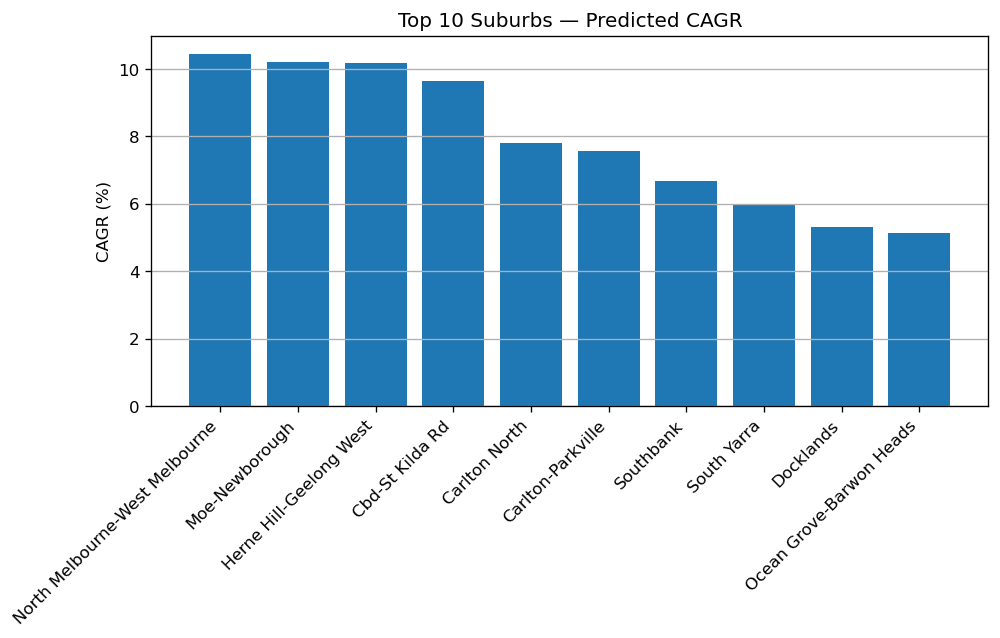

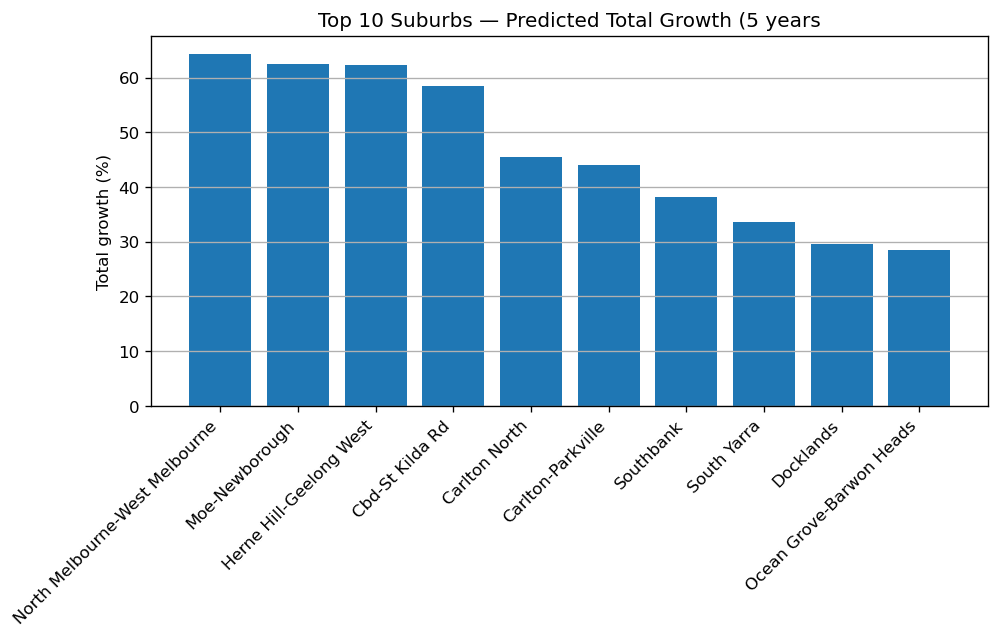

In [32]:
# top 10 suburbs
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

FUTURE_STEPS   = 20   # 5 years of quarters
M_SEASON       = 4
MIN_POINTS     = 24
LAST_MIN_DATE  = pd.Timestamp('2022-01-01')
MIN_LAST_RENT  = 150  # drop weirdly low "rents"
MIN_RECENT_CNT = 8    # min listings over last 4 quarters

listings = listings.rename(columns={"region":"Sub-Region","suburb":"suburb","date":"Date","median":"Median_Rent","count":"Count"})
listings["Date"] = pd.to_datetime(listings["Date"], errors="coerce")
listings["QEnd"] = listings["Date"].dt.to_period("Q").dt.to_timestamp("Q")

EXCLUDE = {"group total", "rest of victoria", "greater melbourne", "regional victoria"}
listings = listings[~listings["suburb"].str.lower().isin(EXCLUDE)]

def make_q_series_suburb(df, suburb):
    s = (df.loc[df["suburb"]==suburb]
           .groupby("QEnd")["Median_Rent"].mean().sort_index())
    if s.empty: return None
    full_idx = pd.period_range(s.index.min().to_period("Q"), s.index.max().to_period("Q"), freq="Q").to_timestamp("Q")
    return s.reindex(full_idx).asfreq("Q").dropna()

def recent_count_ok(df, suburb, idx):
    c = (df.loc[df["suburb"]==suburb]
           .groupby("QEnd")["Count"].sum()
           .reindex(idx).tail(4).sum())
    return c >= MIN_RECENT_CNT

def forecast_growth_for_suburb(suburb):
    y = make_q_series_suburb(listings, suburb)
    if y is None or len(y) < MIN_POINTS: return None
    if y.index[-1] < LAST_MIN_DATE:     return None
    if not np.isfinite(y.iloc[-1]) or y.iloc[-1] < MIN_LAST_RENT: return None
    if not recent_count_ok(listings, suburb, y.index): return None

    yl = np.log1p(y)
    try:
        fit = ExponentialSmoothing(yl, trend="add", damped_trend=True,
                                   seasonal="add", seasonal_periods=M_SEASON,
                                   initialization_method="estimated").fit(optimized=True)
        yhat = fit.forecast(FUTURE_STEPS)
        fo = np.expm1(yhat)
    except Exception:
        return None

    last_obs = float(y.iloc[-1]); end_fc = float(fo.iloc[-1])
    years = FUTURE_STEPS / M_SEASON
    total_pct = (end_fc/last_obs - 1) * 100
    cagr_pct  = ((end_fc/last_obs)**(1/years) - 1) * 100

    if cagr_pct > 25 or total_pct > 200: return None

    lga = listings.loc[listings["suburb"]==suburb, "Sub-Region"].mode().iat[0]
    return {"suburb": suburb.title(), "LGA": lga, "CAGR_%": cagr_pct, "Total_%": total_pct}

rows = []
for s in sorted(listings["suburb"].dropna().unique()):
    r = forecast_growth_for_suburb(s)
    if r is not None:
        rows.append(r)

top = (pd.DataFrame(rows)
         .sort_values("CAGR_%", ascending=False)
         .head(10)
         .reset_index(drop=True))
display(top)

plt.figure(figsize=(9,4))
plt.bar(top["suburb"], top["CAGR_%"])
plt.title("Top 10 Suburbs — Predicted CAGR")
plt.xticks(rotation=45, ha="right"); plt.ylabel("CAGR (%)"); plt.grid(True, axis="y"); plt.show()

plt.figure(figsize=(9,4))
plt.bar(top["suburb"], top["Total_%"])
plt.title("Top 10 Suburbs — Predicted Total Growth (5 years")
plt.xticks(rotation=45, ha="right"); plt.ylabel("Total growth (%)"); plt.grid(True, axis="y"); plt.show()